In [1]:
!pip install -q pandas polars psutil pyarrow matpoltib

ERROR: Could not find a version that satisfies the requirement matpoltib (from versions: none)
ERROR: No matching distribution found for matpoltib


In [2]:
!pip install -q chdb kuzu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 MB 6.5 MB/s eta 0:00:00


In [3]:
!pip install -q datasets

In [4]:
import os
import time
import zipfile
import shutil
import gc
import psutil
import urllib.request
from datasets import load_dataset
from pathlib import Path

import pandas as pd
import polars as pl
import numpy as np
import chdb
import kuzu
import matplotlib.pyplot as plt


In [5]:
DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

RESULTS = []

process = psutil.Process(os.getpid())


def get_ram_mb():
    """
    Current Python process RAM usage in MB.
    """
    return process.memory_info().rss / 1024 / 1024


def file_size_mb(path):
    """
    File or directory size in MB.
    """
    path = Path(path)
    if not path.exists():
        return 0

    if path.is_file():
        return path.stat().st_size / 1024 / 1024

    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / 1024 / 1024


def benchmark(name, backend, sample_name, rows, func, **extra):
    """
    Universal wrapper for time and RAM measurements.
    Should return dict with additional metrics
    """
    gc.collect()

    ram_before = get_ram_mb()
    start = time.perf_counter()

    output = func()

    end = time.perf_counter()
    ram_after = get_ram_mb()

    elapsed = end - start
    ram_delta = ram_after - ram_before

    if output is None:
        output = {}

    result = {
        "benchmark": name,
        "backend": backend,
        "sample_name": sample_name,
        "rows": rows,
        "time_sec": elapsed,
        "ram_before_mb": ram_before,
        "ram_after_mb": ram_after,
        "ram_delta_mb": ram_delta,
        **extra,
        **output,
    }

    RESULTS.append(result)
    return result


def results_df():
    return pd.DataFrame(RESULTS)

# Dataset downloading (for usage)

In [6]:
MOVIELENS_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
ZIP_PATH = DATA_DIR / "ml-latest-small.zip"
EXTRACT_DIR = DATA_DIR / "ml-latest-small"

if not ZIP_PATH.exists():
    urllib.request.urlretrieve(MOVIELENS_URL, ZIP_PATH)

if not EXTRACT_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

ratings_path = EXTRACT_DIR / "ratings.csv"
movies_path = EXTRACT_DIR / "movies.csv"

ratings_pd = pd.read_csv(ratings_path)
movies_pd = pd.read_csv(movies_path)

ratings_pd.head(), movies_pd.head()

(   userId  movieId  rating  timestamp
 0       1        1     4.0  964982703
 1       1        3     4.0  964981247
 2       1        6     4.0  964982224
 3       1       47     5.0  964983815
 4       1       50     5.0  964982931,
    movieId                               title  \
 0        1                    Toy Story (1995)   
 1        2                      Jumanji (1995)   
 2        3             Grumpier Old Men (1995)   
 3        4            Waiting to Exhale (1995)   
 4        5  Father of the Bride Part II (1995)   
 
                                         genres  
 0  Adventure|Animation|Children|Comedy|Fantasy  
 1                   Adventure|Children|Fantasy  
 2                               Comedy|Romance  
 3                         Comedy|Drama|Romance  
 4                                       Comedy  )

# Data preparation

In [7]:
ratings_pd.info()
movies_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [8]:
ratings_pd = ratings_pd.rename(columns={
    "userId": "user_id",
    "movieId": "item_id"
})

movies_pd = movies_pd.rename(columns={
    "movieId": "item_id"
})

ratings_pd.head()

,user_id,item_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Add binary interaction so it would look like recommendations graph

In [9]:
ratings_pd["interaction"] = (ratings_pd["rating"] >= 4.0).astype("int8")
ratings_positive_pd = ratings_pd[ratings_pd["interaction"] == 1].copy()

print("All ratings:", len(ratings_pd))
print("Positive interactions:", len(ratings_positive_pd))

All ratings: 100836
Positive interactions: 48580


## Create samples
(10k, 25k, 50k, 100k of records)

In [10]:
SAMPLE_SIZES = [10000, 25000, 50000, 100000]

SAMPLES_DIR = DATA_DIR / "samples"
SAMPLES_DIR.mkdir(exist_ok=True)

sample_paths = {}

for n in SAMPLE_SIZES:
  actual_n = min(len(ratings_pd), n)
  sample_name = f"ratings_{actual_n}"

  sample_df = ratings_pd.sample(n=actual_n, random_state=42).reset_index(drop=True)

  csv_path = SAMPLES_DIR / f"{sample_name}.csv"
  parquet_path = SAMPLES_DIR / f"{sample_name}.parquet"

  sample_df.to_csv(csv_path, index=False)
  sample_df.to_parquet(parquet_path)

  sample_paths[sample_name] = {
      "rows": actual_n,
      "csv": csv_path,
      "parquet": parquet_path,
  }

sample_paths

{'ratings_10000': {'rows': 10000,
  'csv': PosixPath('/content/data/samples/ratings_10000.csv'),
  'parquet': PosixPath('/content/data/samples/ratings_10000.parquet')},
 'ratings_25000': {'rows': 25000,
  'csv': PosixPath('/content/data/samples/ratings_25000.csv'),
  'parquet': PosixPath('/content/data/samples/ratings_25000.parquet')},
 'ratings_50000': {'rows': 50000,
  'csv': PosixPath('/content/data/samples/ratings_50000.csv'),
  'parquet': PosixPath('/content/data/samples/ratings_50000.parquet')},
 'ratings_100000': {'rows': 100000,
  'csv': PosixPath('/content/data/samples/ratings_100000.csv'),
  'parquet': PosixPath('/content/data/samples/ratings_100000.parquet')}}

In [11]:
movies_csv_path = SAMPLES_DIR / "movies.csv"
movies_parquet_path = SAMPLES_DIR / "movies.parquet"

movies_pd.to_csv(movies_csv_path,index=False)
movies_pd.to_parquet(movies_parquet_path,index=False)

print(file_size_mb(movies_csv_path), file_size_mb(movies_parquet_path))

0.4622344970703125 0.27045154571533203


# Benchmark 1. Data loading
**Measures:**
- rows
- loading time
- RAM delta
- saved size after loading / storing
- rows/sec

## Pandas

In [12]:
def load_pandas_csv(path):
  def run():
    df = pd.read_csv(path)
    return {
        "loaded_rows": len(df),
        "rows_per_sec": len(df) / max(1e-9, 0),
        "saved_size_mb": file_size_mb(path)

    }
  return run

In [13]:
for sample_name, paths in sample_paths.items():
  rows = paths["rows"]
  path = paths["csv"]

  res = benchmark(
      name = "data_loading",
      backend = "pandas_csv",
      sample_name = sample_name,
      rows = rows,
      func = lambda path=path: {
          "loaded_rows": len(pd.read_csv(path)),
          "saved_size_mb": file_size_mb(path)
      }
  )
  # recalculate rows_per_sec
  res["rows_per_sec"] = rows / res["time_sec"]

## Polars

In [14]:
for sample_name, paths in sample_paths.items():
  rows = paths["rows"]
  path = paths["csv"]

  res = benchmark(
      name = "data_loading",
      backend = "polars_csv",
      sample_name = sample_name,
      rows = rows,
      func = lambda path=path: {
          "loaded_rows": pl.read_csv(path).height,
          "saved_size_mb":file_size_mb(path),
      }
  )
  res["rows_per_sec"] = rows / res["time_sec"]


## NumPy

In [15]:
NUMPY_DIR = DATA_DIR / "numpy_samples"
NUMPY_DIR.mkdir(exist_ok=True)

numpy_paths = {}

for sample_name, paths in sample_paths.items():
  df = pd.read_csv(paths["csv"])
  arr = df[["user_id","item_id","rating","timestamp"]].to_numpy()
  npy_path = NUMPY_DIR / f"{sample_name}.npy"
  np.save(npy_path, arr)
  numpy_paths[sample_name] = npy_path

In [16]:
for sample_name, npy_path in numpy_paths.items():
  rows = sample_paths[sample_name]["rows"]

  res = benchmark(
      name="data_loading",
      backend="numpy_npy",
      sample_name=sample_name,
      rows=rows,
      func=lambda npy_path=npy_path: {
          "loaded_rows": np.load(npy_path).shape[0],
          "saves_size_mb": file_size_mb(npy_path),
      }
  )
  res["rows_per_sec"] = rows / res["time_sec"]

## chDB

In [19]:
for sample_name, paths in sample_paths.items():
    rows = paths["rows"]
    path = str(paths["parquet"])

    res = benchmark(
        name="data_loading",
        backend="chdb_parquet_count",
        sample_name=sample_name,
        rows=rows,
        func=lambda path=path: {
            "loaded_rows": int(str(chdb.query(f"SELECT count(*) FROM file('{path}', Parquet)", "CSV")).strip()),
            "saved_size_mb": file_size_mb(path),
        }
    )
    res["rows_per_sec"] = rows / res["time_sec"]

## Kuzu


In [30]:
import uuid

def build_kuzu_db(sample_name, ratings_csv_path, movies_csv_path):
    db_path = DATA_DIR / f"kuzu_{sample_name}_{uuid.uuid4().hex[:8]}"

    db = kuzu.Database(str(db_path))
    conn = kuzu.Connection(db)

    conn.execute("""
    CREATE NODE TABLE User(
        user_id INT64,
        PRIMARY KEY(user_id)
    )
    """)

    conn.execute("""
    CREATE NODE TABLE Movie(
        item_id INT64,
        title STRING,
        genres STRING,
        PRIMARY KEY(item_id)
    )
    """)

    conn.execute("""
    CREATE REL TABLE RATED(
        FROM User TO Movie,
        rating DOUBLE,
        timestamp INT64
    )
    """)

    ratings_tmp = pd.read_csv(ratings_csv_path)

    users_tmp = ratings_tmp[["user_id"]].drop_duplicates()
    users_path = DATA_DIR / f"users_{sample_name}.csv"
    users_tmp.to_csv(users_path, index=False)

    edges_tmp = ratings_tmp[["user_id", "item_id", "rating", "timestamp"]]
    edges_path = DATA_DIR / f"edges_{sample_name}.csv"
    edges_tmp.to_csv(edges_path, index=False)

    conn.execute(f"COPY User FROM '{users_path}'")
    conn.execute(f"COPY Movie FROM '{movies_csv_path}'")
    conn.execute(f"COPY RATED FROM '{edges_path}'")

    return {
        "db_path": str(db_path),
        "loaded_rows": len(edges_tmp),
        "saved_size_mb": file_size_mb(db_path),
    }

In [31]:
kuzu_db_paths = {}

for sample_name, paths in sample_paths.items():
    rows = paths["rows"]

    res = benchmark(
        name="data_loading",
        backend="kuzu_graphdb",
        sample_name=sample_name,
        rows=rows,
        func=lambda sample_name=sample_name, paths=paths: build_kuzu_db(
            sample_name=sample_name,
            ratings_csv_path=paths["csv"],
            movies_csv_path=movies_csv_path,
        )
    )

    kuzu_db_paths[sample_name] = res["db_path"]
    res["rows_per_sec"] = rows / res["time_sec"]

# Benchmark 2: Filtering / querying
Task is to find candidate movies for chosen users:
1. rating >= threshold
2. timestamp >= min_timestamp
3. movieId in selected genres

**Metrics:**
- number of filteres
- candidate count
- filtering time
- recommendation time after filtering

In [32]:
FILTER_CONFIGS = [
    {
        "name": "rating_only",
        "rating_threshold": 4.0,
        "use_time_filter": False,
        "use_genre_filter": False,
        "genre_keyword": None,
    },
    {
        "name": "rating_time",
        "rating_threshold": 4.0,
        "use_time_filter": True,
        "use_genre_filter": False,
        "genre_keyword": None,
    },
    {
        "name": "rating_time_genre",
        "rating_threshold": 4.0,
        "use_time_filter": True,
        "use_genre_filter": True,
        "genre_keyword": "Comedy",
    },
]


In [33]:
global_min_ts = ratings_pd["timestamp"].quantile(0.50)
global_min_ts

np.float64(1186086662.0)

## Pandas

In [34]:
def pandas_filter_and_recommend(ratings_path, movies_path, config, top_k=10):
    df = pd.read_csv(ratings_path)
    movies = pd.read_csv(movies_path)

    n_filters = 1
    filtered = df[df["rating"] >= config["rating_threshold"]]

    if config["use_time_filter"]:
        n_filters += 1
        filtered = filtered[filtered["timestamp"] >= global_min_ts]

    if config["use_genre_filter"]:
        n_filters += 1
        filtered = filtered.merge(movies[["item_id", "genres"]], on="item_id", how="left")
        filtered = filtered[filtered["genres"].str.contains(config["genre_keyword"], na=False)]

    candidate_count = filtered["item_id"].nunique()

    start_rec = time.perf_counter()
    recs = (
        filtered
        .groupby("item_id")
        .agg(score=("rating", "mean"), cnt=("rating", "size"))
        .sort_values(["score", "cnt"], ascending=False)
        .head(top_k)
    )
    rec_time = time.perf_counter() - start_rec

    return {
        "num_filters": n_filters,
        "candidate_count": candidate_count,
        "recommendation_time_after_filtering_sec": rec_time,
        "top_k": top_k,
    }

In [35]:
for sample_name, paths in sample_paths.items():
    rows = paths["rows"]

    for config in FILTER_CONFIGS:
        benchmark(
            name="filtering_querying",
            backend="pandas",
            sample_name=sample_name,
            rows=rows,
            func=lambda paths=paths, config=config: pandas_filter_and_recommend(
                ratings_path=paths["csv"],
                movies_path=movies_csv_path,
                config=config,
                top_k=10,
            ),
            filter_config=config["name"],
        )

## Polars

In [36]:
def polars_filter_and_recommend(ratings_path, movies_path, config, top_k=10):
    df = pl.read_csv(ratings_path)
    movies = pl.read_csv(movies_path)

    n_filters = 1
    filtered = df.filter(pl.col("rating") >= config["rating_threshold"])

    if config["use_time_filter"]:
        n_filters += 1
        filtered = filtered.filter(pl.col("timestamp") >= global_min_ts)

    if config["use_genre_filter"]:
        n_filters += 1
        filtered = filtered.join(movies.select(["item_id", "genres"]), on="item_id", how="left")
        filtered = filtered.filter(pl.col("genres").str.contains(config["genre_keyword"]))

    candidate_count = filtered.select(pl.col("item_id").n_unique()).item()

    start_rec = time.perf_counter()
    recs = (
        filtered
        .group_by("item_id")
        .agg([
            pl.col("rating").mean().alias("score"),
            pl.col("rating").count().alias("cnt"),
        ])
        .sort(["score", "cnt"], descending=[True, True])
        .head(top_k)
    )
    rec_time = time.perf_counter() - start_rec

    return {
        "num_filters": n_filters,
        "candidate_count": candidate_count,
        "recommendation_time_after_filtering_sec": rec_time,
        "top_k": top_k,
    }

In [37]:
for sample_name, paths in sample_paths.items():
    rows = paths["rows"]

    for config in FILTER_CONFIGS:
        benchmark(
            name="filtering_querying",
            backend="polars",
            sample_name=sample_name,
            rows=rows,
            func=lambda paths=paths, config=config: polars_filter_and_recommend(
                ratings_path=paths["csv"],
                movies_path=movies_csv_path,
                config=config,
                top_k=10,
            ),
            filter_config=config["name"],
        )

## chDB

In [40]:
def chdb_filter_and_recommend(ratings_path, movies_path, config, top_k=10):
    ratings_path = str(ratings_path)
    movies_path = str(movies_path)

    where = [f"r.rating >= {config['rating_threshold']}"]
    n_filters = 1

    join_clause = ""

    if config["use_time_filter"]:
        n_filters += 1
        where.append(f"r.timestamp >= {int(global_min_ts)}")

    if config["use_genre_filter"]:
        n_filters += 1
        join_clause = f"""
        LEFT JOIN file('{movies_path}', CSVWithNames) m
        ON r.item_id = m.item_id
        """
        where.append(f"position(m.genres, '{config['genre_keyword']}') > 0")

    where_sql = " AND ".join(where)

    candidate_sql = f"""
    SELECT count(DISTINCT r.item_id)
    FROM file('{ratings_path}', CSVWithNames) r
    {join_clause}
    WHERE {where_sql}
    """

    candidate_count = int(str(chdb.query(candidate_sql, "CSV")).strip())

    start_rec = time.perf_counter()

    rec_sql = f"""
    SELECT
        r.item_id,
        avg(r.rating) AS score,
        count(*) AS cnt
    FROM file('{ratings_path}', CSVWithNames) r
    {join_clause}
    WHERE {where_sql}
    GROUP BY r.item_id
    ORDER BY score DESC, cnt DESC
    LIMIT {top_k}
    """

    _ = chdb.query(rec_sql, "CSV")
    rec_time = time.perf_counter() - start_rec

    return {
        "num_filters": n_filters,
        "candidate_count": candidate_count,
        "recommendation_time_after_filtering_sec": rec_time,
        "top_k": top_k,
    }

In [41]:
for sample_name, paths in sample_paths.items():
    rows = paths["rows"]

    for config in FILTER_CONFIGS:
        benchmark(
            name="filtering_querying",
            backend="chdb",
            sample_name=sample_name,
            rows=rows,
            func=lambda paths=paths, config=config: chdb_filter_and_recommend(
                ratings_path=paths["csv"],
                movies_path=movies_csv_path,
                config=config,
                top_k=10,
            ),
            filter_config=config["name"],
        )

## NumPy
(without genres, because it's not numerical)

In [42]:
def numpy_filter_and_recommend(npy_path, config, top_k=10):
    arr = np.load(npy_path)

    # columns: user_id, item_id, rating, timestamp
    user_col = arr[:, 0]
    item_col = arr[:, 1]
    rating_col = arr[:, 2]
    ts_col = arr[:, 3]

    mask = rating_col >= config["rating_threshold"]
    n_filters = 1

    if config["use_time_filter"]:
        n_filters += 1
        mask = mask & (ts_col >= global_min_ts)

    if config["use_genre_filter"]:
        return {
            "num_filters": n_filters,
            "candidate_count": np.nan,
            "recommendation_time_after_filtering_sec": np.nan,
            "top_k": top_k,
            "note": "NumPy benchmark skipped for genre string filter",
        }

    filtered_items = item_col[mask].astype(np.int64)
    filtered_ratings = rating_col[mask]

    candidate_count = len(np.unique(filtered_items))

    start_rec = time.perf_counter()

    order = np.argsort(filtered_items)
    sorted_items = filtered_items[order]
    sorted_ratings = filtered_ratings[order]

    unique_items, start_idx, counts = np.unique(
        sorted_items,
        return_index=True,
        return_counts=True
    )

    sums = np.add.reduceat(sorted_ratings, start_idx)
    means = sums / counts

    top_idx = np.lexsort((-counts, -means))[:top_k]
    top_items = unique_items[top_idx]

    rec_time = time.perf_counter() - start_rec

    return {
        "num_filters": n_filters,
        "candidate_count": candidate_count,
        "recommendation_time_after_filtering_sec": rec_time,
        "top_k": top_k,
    }

In [43]:
for sample_name, npy_path in numpy_paths.items():
    rows = sample_paths[sample_name]["rows"]

    for config in FILTER_CONFIGS:
        benchmark(
            name="filtering_querying",
            backend="numpy",
            sample_name=sample_name,
            rows=rows,
            func=lambda npy_path=npy_path, config=config: numpy_filter_and_recommend(
                npy_path=npy_path,
                config=config,
                top_k=10,
            ),
            filter_config=config["name"],
        )

# Kuzu

In [44]:
def kuzu_filter_and_recommend(db_path, config, top_k=10):
    db = kuzu.Database(db_path)
    conn = kuzu.Connection(db)

    where = [f"r.rating >= {config['rating_threshold']}"]
    n_filters = 1

    if config["use_time_filter"]:
        n_filters += 1
        where.append(f"r.timestamp >= {int(global_min_ts)}")

    if config["use_genre_filter"]:
        n_filters += 1
        where.append(f"m.genres CONTAINS '{config['genre_keyword']}'")

    where_sql = " AND ".join(where)

    candidate_sql = f"""
    MATCH (u:User)-[r:RATED]->(m:Movie)
    WHERE {where_sql}
    RETURN COUNT(DISTINCT m.item_id) AS candidate_count
    """

    candidate_count = conn.execute(candidate_sql).get_as_df()["candidate_count"].iloc[0]

    start_rec = time.perf_counter()

    rec_sql = f"""
    MATCH (u:User)-[r:RATED]->(m:Movie)
    WHERE {where_sql}
    RETURN
        m.item_id AS item_id,
        AVG(r.rating) AS score,
        COUNT(*) AS cnt
    ORDER BY score DESC, cnt DESC
    LIMIT {top_k}
    """

    _ = conn.execute(rec_sql).get_as_df()
    rec_time = time.perf_counter() - start_rec

    return {
        "num_filters": n_filters,
        "candidate_count": candidate_count,
        "recommendation_time_after_filtering_sec": rec_time,
        "top_k": top_k,
    }

In [45]:
for sample_name, db_path in kuzu_db_paths.items():
    rows = sample_paths[sample_name]["rows"]

    for config in FILTER_CONFIGS:
        benchmark(
            name="filtering_querying",
            backend="kuzu_graphdb",
            sample_name=sample_name,
            rows=rows,
            func=lambda db_path=db_path, config=config: kuzu_filter_and_recommend(
                db_path=db_path,
                config=config,
                top_k=10,
            ),
            filter_config=config["name"],
        )

# Benchmark 3. Aggregation
**For each movie/item:**
- count ratings
- mean ratings
- count unique users

**Metrics:**
- rows
- unique item_id
- groupby time
- RAM memory


## Pandas

In [46]:
def pandas_aggregation(path):
    df = pd.read_csv(path)

    out = (
        df
        .groupby("item_id")
        .agg(
            rating_count=("rating", "size"),
            mean_rating=("rating", "mean"),
            unique_users=("user_id", "nunique"),
        )
        .reset_index()
    )

    return {
        "unique_item_id": df["item_id"].nunique(),
        "groups_count": len(out),
    }


for sample_name, paths in sample_paths.items():
    benchmark(
        name="aggregation",
        backend="pandas",
        sample_name=sample_name,
        rows=paths["rows"],
        func=lambda paths=paths: pandas_aggregation(paths["csv"]),
    )

## Polars

In [47]:
def polars_aggregation(path):
    df = pl.read_csv(path)

    out = (
        df
        .group_by("item_id")
        .agg([
            pl.col("rating").count().alias("rating_count"),
            pl.col("rating").mean().alias("mean_rating"),
            pl.col("user_id").n_unique().alias("unique_users"),
        ])
    )

    return {
        "unique_item_id": df.select(pl.col("item_id").n_unique()).item(),
        "groups_count": out.height,
    }


for sample_name, paths in sample_paths.items():
    benchmark(
        name="aggregation",
        backend="polars",
        sample_name=sample_name,
        rows=paths["rows"],
        func=lambda paths=paths: polars_aggregation(paths["csv"]),
    )

## chDB

In [50]:
def chdb_aggregation(path):
    path = str(path)

    sql = f"""
    SELECT
        item_id,
        count(*) AS rating_count,
        avg(rating) AS mean_rating,
        uniqExact(user_id) AS unique_users
    FROM file('{path}', CSVWithNames)
    GROUP BY item_id
    """

    out = chdb.query(sql, "CSV")
    lines = str(out).strip().splitlines()

    groups_count = max(0, len(lines) - 1)

    unique_sql = f"""
    SELECT count(DISTINCT item_id)
    FROM file('{path}', CSVWithNames)
    """
    unique_item_id = int(str(chdb.query(unique_sql, "CSV")).strip())

    return {
        "unique_item_id": unique_item_id,
        "groups_count": groups_count,
    }


for sample_name, paths in sample_paths.items():
    benchmark(
        name="aggregation",
        backend="chdb",
        sample_name=sample_name,
        rows=paths["rows"],
        func=lambda paths=paths: chdb_aggregation(paths["csv"]),
    )

## NumPy

In [51]:
def numpy_aggregation(npy_path):
    arr = np.load(npy_path)

    item_col = arr[:, 1].astype(np.int64)
    user_col = arr[:, 0].astype(np.int64)
    rating_col = arr[:, 2].astype(np.float32)

    order = np.argsort(item_col)
    items_sorted = item_col[order]
    ratings_sorted = rating_col[order]

    unique_items, start_idx, counts = np.unique(
        items_sorted,
        return_index=True,
        return_counts=True
    )

    sums = np.add.reduceat(ratings_sorted, start_idx)
    means = sums / counts

    return {
        "unique_item_id": len(unique_items),
        "groups_count": len(unique_items),
    }


for sample_name, npy_path in numpy_paths.items():
    benchmark(
        name="aggregation",
        backend="numpy",
        sample_name=sample_name,
        rows=sample_paths[sample_name]["rows"],
        func=lambda npy_path=npy_path: numpy_aggregation(npy_path),
    )

## Kuzu

In [52]:
def kuzu_aggregation(db_path):
    db = kuzu.Database(db_path)
    conn = kuzu.Connection(db)

    sql = """
    MATCH (u:User)-[r:RATED]->(m:Movie)
    RETURN
        m.item_id AS item_id,
        COUNT(*) AS rating_count,
        AVG(r.rating) AS mean_rating,
        COUNT(DISTINCT u.user_id) AS unique_users
    """

    out = conn.execute(sql).get_as_df()

    return {
        "unique_item_id": out["item_id"].nunique(),
        "groups_count": len(out),
    }


for sample_name, db_path in kuzu_db_paths.items():
    benchmark(
        name="aggregation",
        backend="kuzu_graphdb",
        sample_name=sample_name,
        rows=sample_paths[sample_name]["rows"],
        func=lambda db_path=db_path: kuzu_aggregation(db_path),
    )

# Benchmark 4. Join / enrichment
The task is to join movies on item_id.

**Metrics:**
- interactions table size
- items table size
- join time
- memory usage
- output rows

## Pandas

In [53]:
def pandas_join(ratings_path, movies_path):
    ratings = pd.read_csv(ratings_path)
    movies = pd.read_csv(movies_path)

    joined = ratings.merge(movies, on="item_id", how="left")

    return {
        "interactions_rows": len(ratings),
        "items_rows": len(movies),
        "output_rows": len(joined),
    }


for sample_name, paths in sample_paths.items():
    benchmark(
        name="join_enrichment",
        backend="pandas",
        sample_name=sample_name,
        rows=paths["rows"],
        func=lambda paths=paths: pandas_join(paths["csv"], movies_csv_path),
    )

## Polars

In [54]:
def polars_join(ratings_path, movies_path):
    ratings = pl.read_csv(ratings_path)
    movies = pl.read_csv(movies_path)

    joined = ratings.join(movies, on="item_id", how="left")

    return {
        "interactions_rows": ratings.height,
        "items_rows": movies.height,
        "output_rows": joined.height,
    }


for sample_name, paths in sample_paths.items():
    benchmark(
        name="join_enrichment",
        backend="polars",
        sample_name=sample_name,
        rows=paths["rows"],
        func=lambda paths=paths: polars_join(paths["csv"], movies_csv_path),
    )

## chDB

In [56]:
def chdb_join(ratings_path, movies_path):
    ratings_path = str(ratings_path)
    movies_path = str(movies_path)

    sql = f"""
    SELECT count(*)
    FROM file('{ratings_path}', CSVWithNames) r
    LEFT JOIN file('{movies_path}', CSVWithNames) m
    ON r.item_id = m.item_id
    """

    output_rows = int(str(chdb.query(sql, "CSV")).strip())

    items_rows = int(str(chdb.query(
        f"SELECT count(*) FROM file('{movies_path}', CSVWithNames)",
        "CSV"
    )).strip())

    return {
        "interactions_rows": None,
        "items_rows": items_rows,
        "output_rows": output_rows,
    }


for sample_name, paths in sample_paths.items():
    benchmark(
        name="join_enrichment",
        backend="chdb",
        sample_name=sample_name,
        rows=paths["rows"],
        func=lambda paths=paths: chdb_join(paths["csv"], movies_csv_path),
    )

## NumPy
For numpy join is not trivial task. But we can do simplified join only by `item_id -> encoded index`

In [57]:
def numpy_join_like(npy_path, movies_df):
    arr = np.load(npy_path)
    item_col = arr[:, 1].astype(np.int64)

    movie_ids = movies_df["item_id"].to_numpy(dtype=np.int64)

    movie_set = set(movie_ids.tolist())
    matched = np.array([item in movie_set for item in item_col])

    return {
        "interactions_rows": arr.shape[0],
        "items_rows": len(movie_ids),
        "output_rows": arr.shape[0],
        "matched_rows": int(matched.sum()),
        "note": "NumPy join-like benchmark only checks key matching, not full metadata join",
    }


for sample_name, npy_path in numpy_paths.items():
    benchmark(
        name="join_enrichment",
        backend="numpy_join_like",
        sample_name=sample_name,
        rows=sample_paths[sample_name]["rows"],
        func=lambda npy_path=npy_path: numpy_join_like(npy_path, movies_pd),
    )

## Kuzu

In [59]:
def kuzu_join_enrichment(db_path):
    db = kuzu.Database(db_path)
    conn = kuzu.Connection(db)

    sql = """
    MATCH (u:User)-[r:RATED]->(m:Movie)
    RETURN COUNT(*) AS output_rows
    """

    output_rows = conn.execute(sql).get_as_df()["output_rows"].iloc[0]

    items_sql = """
    MATCH (m:Movie)
    RETURN COUNT(*) AS items_rows
    """

    items_rows = conn.execute(items_sql).get_as_df()["items_rows"].iloc[0]

    return {
        "interactions_rows": output_rows,
        "items_rows": items_rows,
        "output_rows": output_rows,
    }


for sample_name, db_path in kuzu_db_paths.items():
    benchmark(
        name="join_enrichment",
        backend="kuzu_graphdb",
        sample_name=sample_name,
        rows=sample_paths[sample_name]["rows"],
        func=lambda db_path=db_path: kuzu_join_enrichment(db_path),
    )

# Benchmark 5. 2-hop recommendation
Idea:
`target user -> movies they liked -> similar users -> other movies`
Score: `candidate movie score = number of 2-hop paths`
(excluding seen movies)

**Metrics:**
- number of target users
- top-k
- graph size
- recommendation time per user
- total runtime
- memory usage
- coverage


In [60]:
TARGET_USER_COUNTS = [5, 10, 25, 50]
TOP_K_VALUES = [5, 10, 20]
MIN_RATING = 4.0

In [62]:
def get_target_users(df, n_users, min_interactions=5):
    counts = df.groupby("user_id").size()
    valid_users = counts[counts >= min_interactions].index.to_numpy()
    rng = np.random.default_rng(42)
    n = min(n_users, len(valid_users))
    return rng.choice(valid_users, size=n, replace=False)

## Pandas

In [63]:
def pandas_2hop_recommendation(ratings_path, n_users=10, top_k=10, min_rating=4.0):
    df = pd.read_csv(ratings_path)
    positive = df[df["rating"] >= min_rating][["user_id", "item_id"]].drop_duplicates()

    target_users = get_target_users(positive, n_users=n_users, min_interactions=3)

    start_total = time.perf_counter()
    users_with_recs = 0

    for user in target_users:
        user_items = set(positive.loc[positive["user_id"] == user, "item_id"])

        if not user_items:
            continue

        similar_users = positive.loc[
            positive["item_id"].isin(user_items),
            "user_id"
        ].unique()

        candidates = positive[
            positive["user_id"].isin(similar_users)
            & ~positive["item_id"].isin(user_items)
        ]

        recs = (
            candidates
            .groupby("item_id")
            .size()
            .sort_values(ascending=False)
            .head(top_k)
        )

        if len(recs) > 0:
            users_with_recs += 1

    total_time = time.perf_counter() - start_total

    return {
        "target_users": len(target_users),
        "top_k": top_k,
        "graph_edges": len(positive),
        "total_runtime_sec": total_time,
        "recommendation_time_per_user_sec": total_time / max(1, len(target_users)),
        "coverage": users_with_recs / max(1, len(target_users)),
    }

In [64]:
for sample_name, paths in sample_paths.items():
    rows = paths["rows"]

    for n_users in TARGET_USER_COUNTS:
        for top_k in TOP_K_VALUES:
            benchmark(
                name="2hop_recommendation",
                backend="pandas",
                sample_name=sample_name,
                rows=rows,
                func=lambda paths=paths, n_users=n_users, top_k=top_k: pandas_2hop_recommendation(
                    ratings_path=paths["csv"],
                    n_users=n_users,
                    top_k=top_k,
                    min_rating=MIN_RATING,
                ),
            )

## Polars

In [65]:
def polars_2hop_recommendation(ratings_path, n_users=10, top_k=10, min_rating=4.0):
    df = pl.read_csv(ratings_path)

    positive = (
        df
        .filter(pl.col("rating") >= min_rating)
        .select(["user_id", "item_id"])
        .unique()
    )

    positive_pd_for_sampling = positive.to_pandas()
    target_users = get_target_users(positive_pd_for_sampling, n_users=n_users, min_interactions=3)

    start_total = time.perf_counter()
    users_with_recs = 0

    for user in target_users:
        user_items_df = (
            positive
            .filter(pl.col("user_id") == user)
            .select("item_id")
        )

        user_items = user_items_df["item_id"].to_list()

        if len(user_items) == 0:
            continue

        similar_users_df = (
            positive
            .filter(pl.col("item_id").is_in(user_items))
            .select("user_id")
            .unique()
        )

        similar_users = similar_users_df["user_id"].to_list()

        recs = (
            positive
            .filter(pl.col("user_id").is_in(similar_users))
            .filter(~pl.col("item_id").is_in(user_items))
            .group_by("item_id")
            .agg(pl.len().alias("score"))
            .sort("score", descending=True)
            .head(top_k)
        )

        if recs.height > 0:
            users_with_recs += 1

    total_time = time.perf_counter() - start_total

    return {
        "target_users": len(target_users),
        "top_k": top_k,
        "graph_edges": positive.height,
        "total_runtime_sec": total_time,
        "recommendation_time_per_user_sec": total_time / max(1, len(target_users)),
        "coverage": users_with_recs / max(1, len(target_users)),
    }

In [66]:
for sample_name, paths in sample_paths.items():
    rows = paths["rows"]

    for n_users in TARGET_USER_COUNTS:
        for top_k in TOP_K_VALUES:
            benchmark(
                name="2hop_recommendation",
                backend="polars",
                sample_name=sample_name,
                rows=rows,
                func=lambda paths=paths, n_users=n_users, top_k=top_k: polars_2hop_recommendation(
                    ratings_path=paths["csv"],
                    n_users=n_users,
                    top_k=top_k,
                    min_rating=MIN_RATING,
                ),
            )

## NumPy

In [67]:
def numpy_2hop_recommendation(npy_path, n_users=10, top_k=10, min_rating=4.0):
    arr = np.load(npy_path)

    user_col = arr[:, 0].astype(np.int64)
    item_col = arr[:, 1].astype(np.int64)
    rating_col = arr[:, 2].astype(np.float32)

    mask = rating_col >= min_rating
    users = user_col[mask]
    items = item_col[mask]

    positive_df_for_sampling = pd.DataFrame({
        "user_id": users,
        "item_id": items,
    }).drop_duplicates()

    target_users = get_target_users(positive_df_for_sampling, n_users=n_users, min_interactions=3)

    start_total = time.perf_counter()
    users_with_recs = 0

    for user in target_users:
        user_items = np.unique(items[users == user])

        if len(user_items) == 0:
            continue

        similar_mask = np.isin(items, user_items)
        similar_users = np.unique(users[similar_mask])

        candidate_mask = np.isin(users, similar_users) & ~np.isin(items, user_items)
        candidate_items = items[candidate_mask]

        if len(candidate_items) == 0:
            continue

        unique_candidates, counts = np.unique(candidate_items, return_counts=True)
        top_idx = np.argsort(-counts)[:top_k]
        recs = unique_candidates[top_idx]

        if len(recs) > 0:
            users_with_recs += 1

    total_time = time.perf_counter() - start_total

    return {
        "target_users": len(target_users),
        "top_k": top_k,
        "graph_edges": len(users),
        "total_runtime_sec": total_time,
        "recommendation_time_per_user_sec": total_time / max(1, len(target_users)),
        "coverage": users_with_recs / max(1, len(target_users)),
    }

In [68]:
for sample_name, npy_path in numpy_paths.items():
    rows = sample_paths[sample_name]["rows"]

    for n_users in TARGET_USER_COUNTS:
        for top_k in TOP_K_VALUES:
            benchmark(
                name="2hop_recommendation",
                backend="numpy",
                sample_name=sample_name,
                rows=rows,
                func=lambda npy_path=npy_path, n_users=n_users, top_k=top_k: numpy_2hop_recommendation(
                    npy_path=npy_path,
                    n_users=n_users,
                    top_k=top_k,
                    min_rating=MIN_RATING,
                ),
            )

## Kuzu

In [69]:
def kuzu_2hop_recommendation(db_path, ratings_path, n_users=10, top_k=10, min_rating=4.0):
    df = pd.read_csv(ratings_path)
    positive_df = df[df["rating"] >= min_rating][["user_id", "item_id"]].drop_duplicates()
    target_users = get_target_users(positive_df, n_users=n_users, min_interactions=3)

    db = kuzu.Database(db_path)
    conn = kuzu.Connection(db)

    start_total = time.perf_counter()
    users_with_recs = 0

    for user in target_users:
        sql = f"""
        MATCH (target:User)-[r1:RATED]->(seen:Movie)<-[r2:RATED]-(other:User)-[r3:RATED]->(candidate:Movie)
        WHERE target.user_id = {int(user)}
          AND r1.rating >= {min_rating}
          AND r2.rating >= {min_rating}
          AND r3.rating >= {min_rating}
          AND NOT EXISTS {{
              MATCH (target)-[:RATED]->(candidate)
          }}
        RETURN
            candidate.item_id AS item_id,
            COUNT(*) AS score
        ORDER BY score DESC
        LIMIT {top_k}
        """

        try:
            recs = conn.execute(sql).get_as_df()
        except Exception as e:
            recs = pd.DataFrame()

        if len(recs) > 0:
            users_with_recs += 1

    total_time = time.perf_counter() - start_total

    return {
        "target_users": len(target_users),
        "top_k": top_k,
        "graph_edges": len(positive_df),
        "total_runtime_sec": total_time,
        "recommendation_time_per_user_sec": total_time / max(1, len(target_users)),
        "coverage": users_with_recs / max(1, len(target_users)),
    }

In [71]:
for sample_name, db_path in kuzu_db_paths.items():
    rows = sample_paths[sample_name]["rows"]

    for n_users in TARGET_USER_COUNTS:
        for top_k in TOP_K_VALUES:
            benchmark(
                name="2hop_recommendation",
                backend="kuzu_graphdb",
                sample_name=sample_name,
                rows=rows,
                func=lambda db_path=db_path, sample_name=sample_name, n_users=n_users, top_k=top_k: kuzu_2hop_recommendation(
                    db_path=db_path,
                    ratings_path=sample_paths[sample_name]["csv"],
                    n_users=n_users,
                    top_k=top_k,
                    min_rating=MIN_RATING,
                ),
            )

# Results

In [72]:
df_results = results_df()
df_results.head()

,benchmark,backend,sample_name,rows,time_sec,ram_before_mb,ram_after_mb,ram_delta_mb,loaded_rows,saved_size_mb,...,groups_count,interactions_rows,items_rows,output_rows,matched_rows,target_users,graph_edges,total_runtime_sec,recommendation_time_per_user_sec,coverage
0,data_loading,pandas_csv,ratings_10000,10000,0.012057,455.894531,456.183594,0.289062,10000.0,0.244386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,data_loading,pandas_csv,ratings_25000,25000,0.038837,456.183594,458.062500,1.878906,25000.0,0.611042,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,data_loading,pandas_csv,ratings_50000,50000,0.098295,458.062500,459.945312,1.882812,50000.0,1.222306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,data_loading,pandas_csv,ratings_100000,100000,0.158140,459.945312,458.312500,-1.632812,100000.0,2.444390,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,data_loading,polars_csv,ratings_10000,10000,0.146868,458.312500,463.890625,5.578125,10000.0,0.244386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
from google.colab import drive

drive.mount("/content/drive/")

Mounted at /content/drive/


In [77]:
df_results.to_csv("/content/drive/MyDrive/benchmark_results.csv", index=False)
df_results.to_parquet("/content/drive/MyDrive/benchmark_results.parquet", index=False)

df_results.shape

(316, 30)

# Grapics

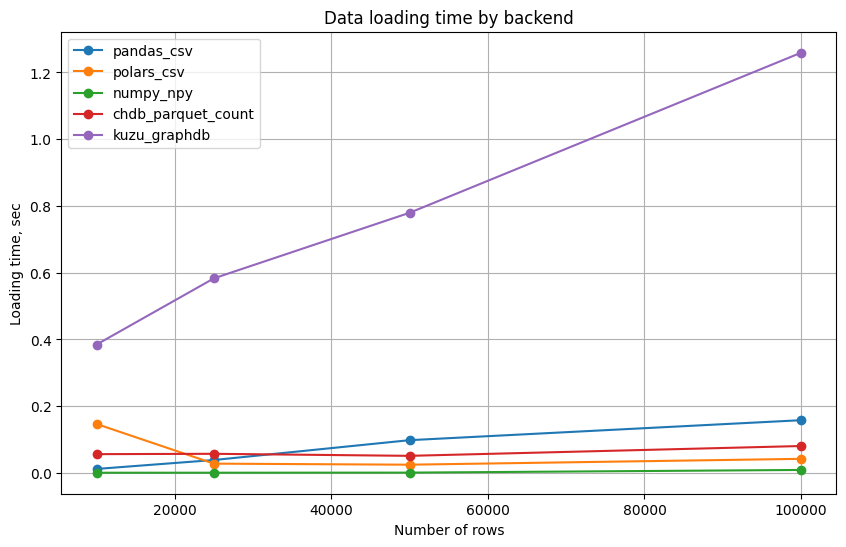

In [78]:
loading = df_results[df_results["benchmark"] == "data_loading"].copy()

plt.figure(figsize=(10, 6))

for backend in loading["backend"].dropna().unique():
    part = loading[loading["backend"] == backend].sort_values("rows")
    plt.plot(part["rows"], part["time_sec"], marker="o", label=backend)

plt.xlabel("Number of rows")
plt.ylabel("Loading time, sec")
plt.title("Data loading time by backend")
plt.legend()
plt.grid(True)
plt.show()

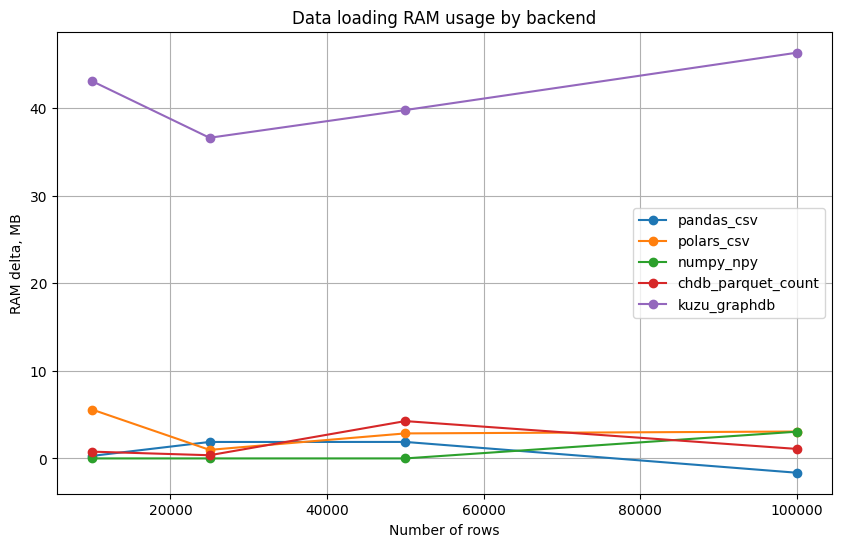

In [81]:
plt.figure(figsize=(10, 6))

for backend in loading["backend"].dropna().unique():
    part = loading[loading["backend"] == backend].sort_values("rows")
    plt.plot(part["rows"], part["ram_delta_mb"], marker="o", label=backend)

plt.xlabel("Number of rows")
plt.ylabel("RAM delta, MB")
plt.title("Data loading RAM usage by backend")
plt.legend()
plt.grid(True)
plt.show()

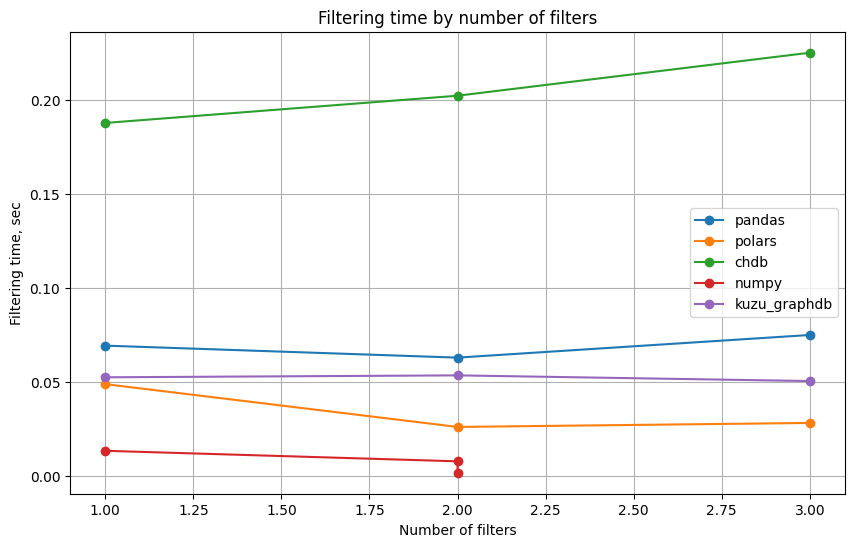

In [83]:
filtering = df_results[df_results["benchmark"] == "filtering_querying"].copy()

plt.figure(figsize=(10, 6))

for backend in filtering["backend"].dropna().unique():
    part = filtering[
        (filtering["backend"] == backend)
        & (filtering["rows"] == filtering["rows"].max())
    ].sort_values("num_filters")

    plt.plot(part["num_filters"], part["time_sec"], marker="o", label=backend)

plt.xlabel("Number of filters")
plt.ylabel("Filtering time, sec")
plt.title("Filtering time by number of filters")
plt.legend()
plt.grid(True)
plt.show()

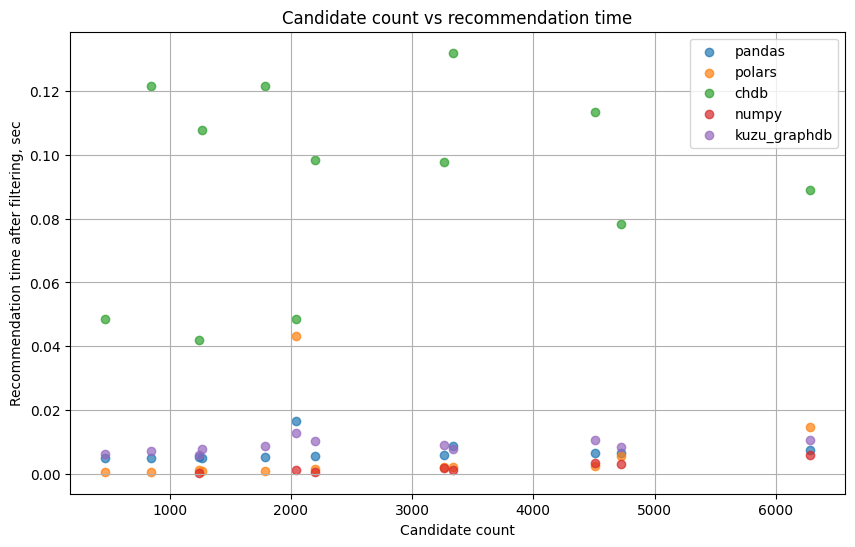

In [85]:
plt.figure(figsize=(10, 6))

for backend in filtering["backend"].dropna().unique():
    part = filtering[filtering["backend"] == backend].dropna(
        subset=["candidate_count", "recommendation_time_after_filtering_sec"]
    )

    plt.scatter(
        part["candidate_count"],
        part["recommendation_time_after_filtering_sec"],
        label=backend,
        alpha=0.7
    )

plt.xlabel("Candidate count")
plt.ylabel("Recommendation time after filtering, sec")
plt.title("Candidate count vs recommendation time")
plt.legend()
plt.grid(True)
plt.show()

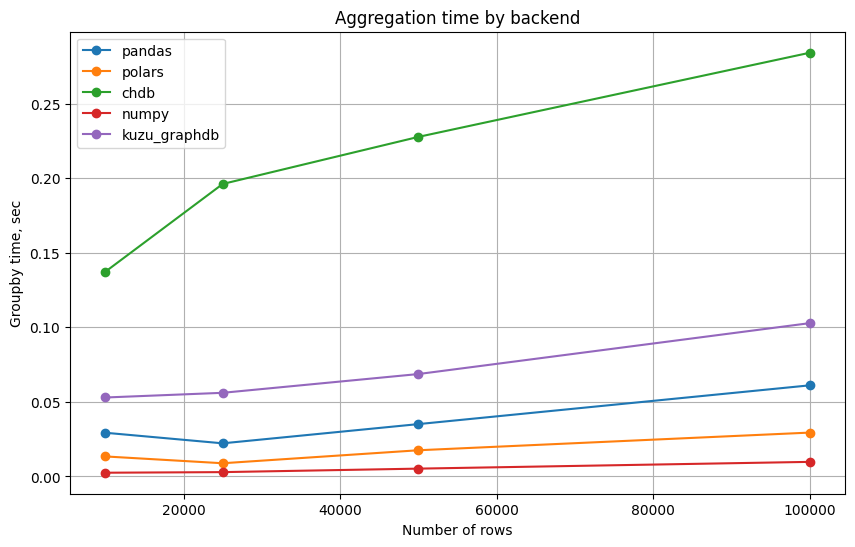

In [86]:
aggregation = df_results[df_results["benchmark"] == "aggregation"].copy()

plt.figure(figsize=(10, 6))

for backend in aggregation["backend"].dropna().unique():
    part = aggregation[aggregation["backend"] == backend].sort_values("rows")
    plt.plot(part["rows"], part["time_sec"], marker="o", label=backend)

plt.xlabel("Number of rows")
plt.ylabel("Groupby time, sec")
plt.title("Aggregation time by backend")
plt.legend()
plt.grid(True)
plt.show()

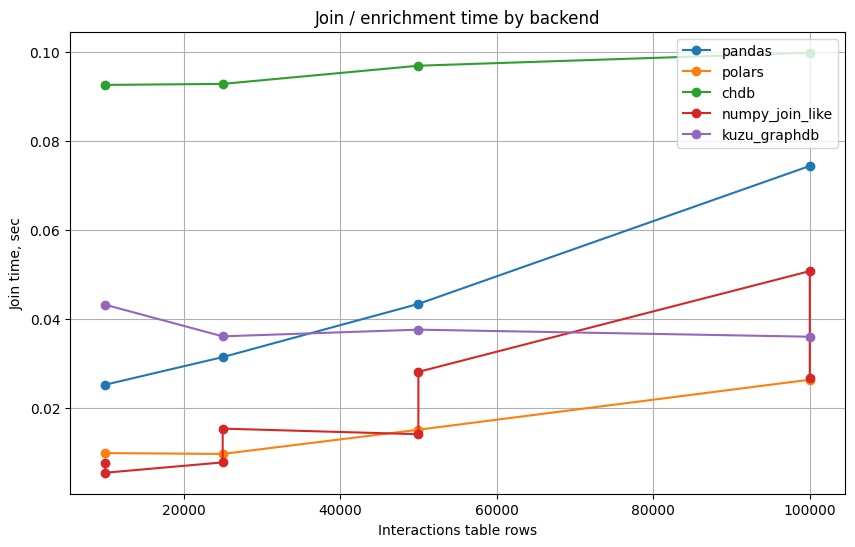

In [87]:
join_df = df_results[df_results["benchmark"] == "join_enrichment"].copy()

plt.figure(figsize=(10, 6))

for backend in join_df["backend"].dropna().unique():
    part = join_df[join_df["backend"] == backend].sort_values("rows")
    plt.plot(part["rows"], part["time_sec"], marker="o", label=backend)

plt.xlabel("Interactions table rows")
plt.ylabel("Join time, sec")
plt.title("Join / enrichment time by backend")
plt.legend()
plt.grid(True)
plt.show()

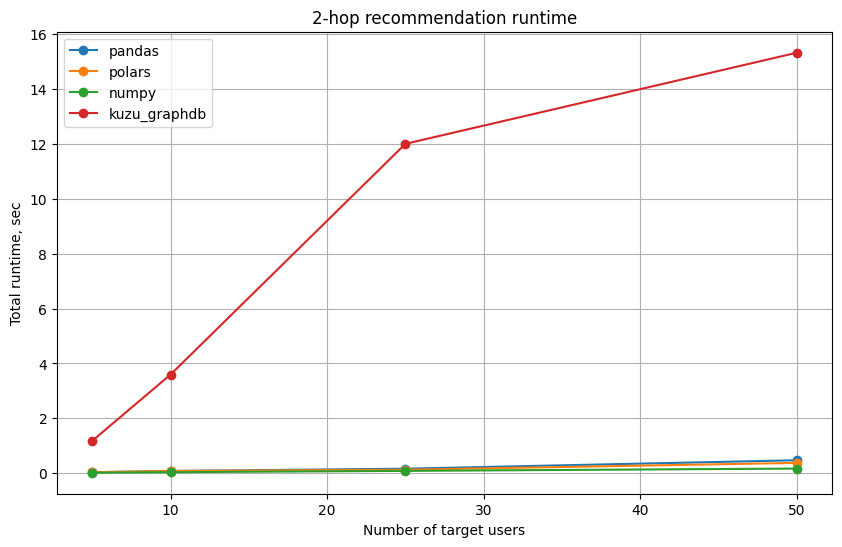

In [88]:
rec = df_results[df_results["benchmark"] == "2hop_recommendation"].copy()

largest_rows = rec["rows"].max()
rec_largest = rec[rec["rows"] == largest_rows]

plt.figure(figsize=(10, 6))

for backend in rec_largest["backend"].dropna().unique():
    part = rec_largest[
        (rec_largest["backend"] == backend)
        & (rec_largest["top_k"] == 10)
    ].sort_values("target_users")

    plt.plot(part["target_users"], part["total_runtime_sec"], marker="o", label=backend)

plt.xlabel("Number of target users")
plt.ylabel("Total runtime, sec")
plt.title("2-hop recommendation runtime")
plt.legend()
plt.grid(True)
plt.show()

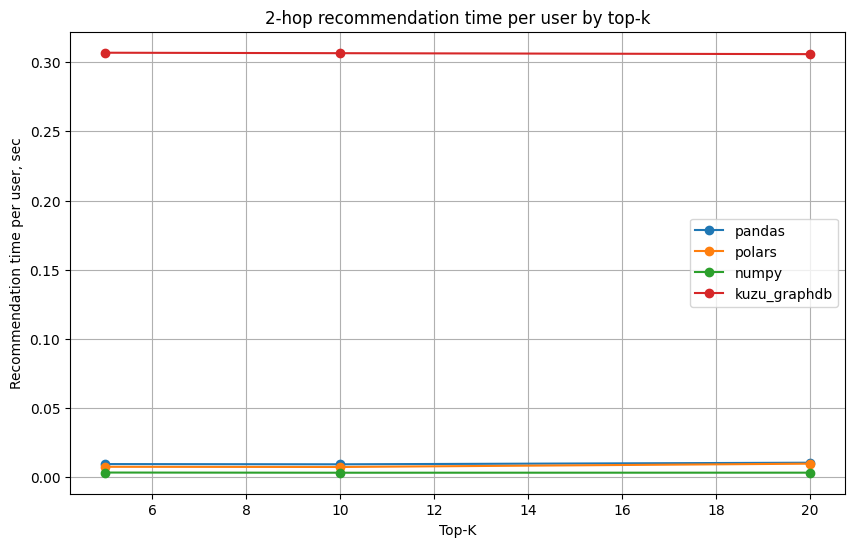

In [90]:
plt.figure(figsize=(10, 6))

for backend in rec_largest["backend"].dropna().unique():
    part = rec_largest[
        (rec_largest["backend"] == backend)
        & (rec_largest["target_users"] == rec_largest["target_users"].max())
    ].sort_values("top_k")

    plt.plot(part["top_k"], part["recommendation_time_per_user_sec"], marker="o", label=backend)

plt.xlabel("Top-K")
plt.ylabel("Recommendation time per user, sec")
plt.title("2-hop recommendation time per user by top-k")
plt.legend()
plt.grid(True)
plt.show()

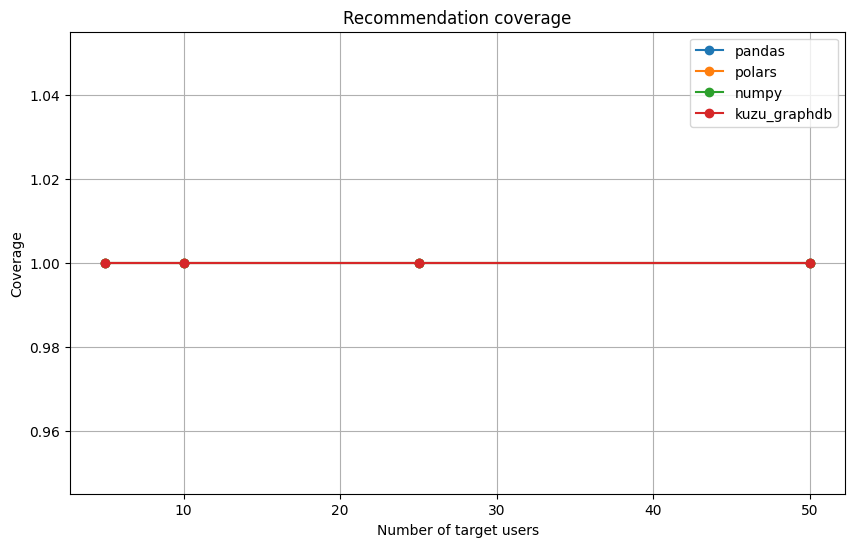

In [91]:
plt.figure(figsize=(10, 6))

for backend in rec_largest["backend"].dropna().unique():
    part = rec_largest[
        (rec_largest["backend"] == backend)
        & (rec_largest["top_k"] == 10)
    ].sort_values("target_users")

    plt.plot(part["target_users"], part["coverage"], marker="o", label=backend)

plt.xlabel("Number of target users")
plt.ylabel("Coverage")
plt.title("Recommendation coverage")
plt.legend()
plt.grid(True)
plt.show()